# 动手实验二：自己加边、自己数三角形

本页先写一个完全独立的小型计数器，再复现提交论文中的精确阶梯与 KK 函数。

In [1]:
from itertools import combinations
import math
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
plt.rcParams['font.sans-serif']=['Microsoft YaHei','SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus']=False
H={(1,2),(1,3),(1,4),(1,5),(6,7),(8,9)}
def norm(edges): return {tuple(sorted(e)) for e in edges}
def triangles(n,edges):
    e=norm(edges)
    return [abc for abc in combinations(range(1,n+1),3) if all(tuple(sorted(x)) in e for x in combinations(abc,2))]
print('固定图 H 的边数:',len(H),'三角形:',triangles(9,H))

固定图 H 的边数: 6 三角形: []


## 实验 A：第一个三角形只需再加边 23

注意 $E(n,k)$ 数的是**总边数**，所以固定 6 边加 1 边得到 7。

In [2]:
edges=H|{(2,3)}
print('总边数:',len(edges))
print('三角形:',triangles(9,edges))

总边数: 7
三角形: [(1, 2, 3)]


## 实验 B：一条边可能同时闭合多个三角形

改变 `extra`，观察新增边的共同邻居。

In [3]:
extra={(2,3),(2,4),(3,4)}
edges=H|extra
print('总边数:',len(edges))
print('三角形数:',len(triangles(9,edges)))
print('三角形列表:',triangles(9,edges))

总边数: 9
三角形数: 4
三角形列表: [(1, 2, 3), (1, 2, 4), (1, 3, 4), (2, 3, 4)]


## 实验 C：KK 工厂

把 $m$ 写成 $\binom q2+r$，完全图 $K_q$ 贡献 $\binom q3$ 个三角形，新点再贡献 $\binom r2$ 个。

In [4]:
def c2(n): return n*(n-1)//2
def c3(n): return n*(n-1)*(n-2)//6
def decompose(m):
    q=1
    while c2(q+1)<=m:q+=1
    return q,m-c2(q)
def KK(m):
    q,r=decompose(m);return c3(q)+c2(r)
for m in [7,8,9,28,29,30]:
    q,r=decompose(m);print(f'm={m}: q={q}, r={r}, KK={KK(m)}')

m=7: q=4, r=1, KK=4
m=8: q=4, r=2, KK=5
m=9: q=4, r=3, KK=7
m=28: q=8, r=0, KK=56
m=29: q=8, r=1, KK=56
m=30: q=8, r=2, KK=57


## 实验 D：读取提交版精确阶梯

这里录入的是论文表中的 $n=9$ 精确答案。台阶不一定每次只升 1，例如 35 个三角形需 22 边，而 36 个需 24 边。

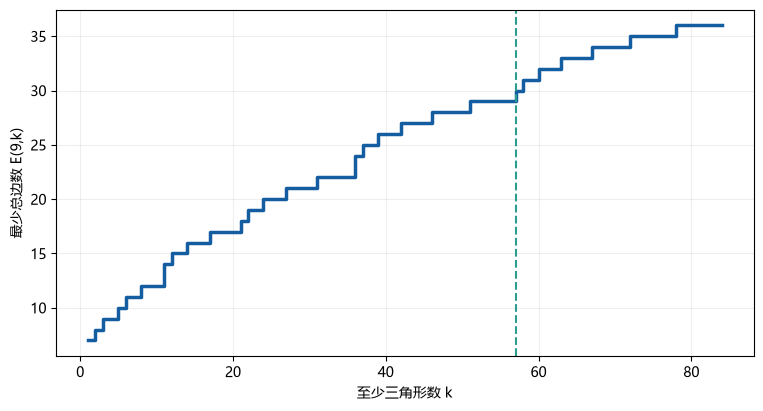

In [5]:
ranges=[(1,1,7),(2,2,8),(3,4,9),(5,5,10),(6,7,11),(8,10,12),(11,11,14),(12,13,15),(14,16,16),(17,20,17),(21,21,18),(22,23,19),(24,26,20),(27,30,21),(31,35,22),(36,36,24),(37,38,25),(39,41,26),(42,45,27),(46,50,28),(51,56,29),(57,57,30),(58,59,31),(60,62,32),(63,66,33),(67,71,34),(72,77,35),(78,84,36)]
E={}
for lo,hi,m in ranges:
    for k in range(lo,hi+1):E[k]=m
ks=sorted(E);plt.figure(figsize=(9,4.5));plt.step(ks,[E[k] for k in ks],where='post',lw=2.5,color='#145DA0');plt.axvline(57,color='#2A9D8F',ls='--');plt.xlabel('至少三角形数 k');plt.ylabel('最少总边数 E(9,k)');plt.grid(alpha=.2);plt.show()

## 实验 E：真的穷举一个小世界

$K_6$ 只有 15 条可能边，所以全部图共有 $2^{15}=32768$ 个。下方真正遍历它们，并把每个边预算的最大三角形数与 KK 公式比较。

In [6]:
all_edges=list(combinations(range(6),2));best=[0]*16
for mask in range(1<<len(all_edges)):
    m=mask.bit_count();edge_set={all_edges[i] for i in range(15) if mask>>i&1}
    t=sum(all(tuple(sorted(e)) in edge_set for e in combinations(tri,2)) for tri in combinations(range(6),3))
    best[m]=max(best[m],t)
print('m  穷举最大值  KK(m)')
for m,(a,b) in enumerate(zip(best,[KK(x) for x in range(16)])):
    print(f'{m:2d} {a:10d} {b:7d}')
assert best==[KK(x) for x in range(16)]

m  穷举最大值  KK(m)
 0          0       0
 1          0       0
 2          0       0
 3          1       1
 4          1       1
 5          2       2
 6          4       4
 7          4       4
 8          5       5
 9          7       7
10         10      10
11         10      10
12         11      11
13         13      13
14         16      16
15         20      20


## 结论记录

1. 三角形计数只看原顶点间是否两两连边，交叉点不算新顶点。
2. 见证边集能证明“做得到”，精确最优还需要“不能更少”的证据。
3. 小世界可以真穷举；正式 $n=9,10$ 前沿使用三套独立求解后端和独立见证重计数。
4. 论文图中曾写 $M_n(m)$；本书统一记为 $T_n(m)$，两者指同一个最大三角形前沿。